In [1]:
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import platform

# 한글 폰트 설정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [3]:
# 2. 클래스 이름 정의 (CIFAR-10 공식 순서)
classes = [
    "비행기", "자동차", "새", "고양이", "사슴",
    "개", "개구리", "말", "배", "트럭",
]

# 3. 데이터 차원 확인
print("==== 데이터 구조 확인 ====")
print(
    f"Train 이미지 차원: {x_train.shape}"
)  # (50000, 32, 32, 3) -> 5만장, 32x32 해상도, RGB 3채널
print(f"Train 라벨 차원: {y_train.shape}")  # (50000, 1)
print(f"Test 이미지 차원: {x_test.shape}")  # (10000, 32, 32, 3)
print(f"테스트 데이터 비율: {len(x_test) / (len(x_train) + len(x_test)) * 100:.1f}%")
print(f"픽셀 최솟값: {x_train.min()}, 최댓값: {x_train.max()}")

==== 데이터 구조 확인 ====
Train 이미지 차원: (50000, 32, 32, 3)
Train 라벨 차원: (50000, 1)
Test 이미지 차원: (10000, 32, 32, 3)
테스트 데이터 비율: 16.7%
픽셀 최솟값: 0, 최댓값: 255


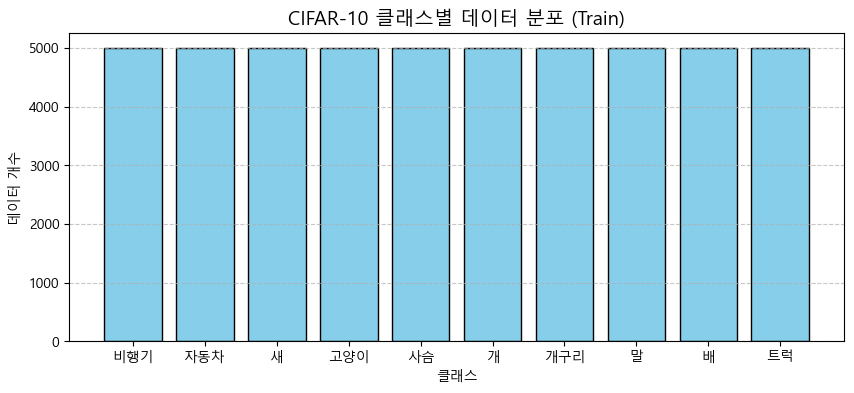

클래스별 개수: {'비행기': np.int64(5000), '자동차': np.int64(5000), '새': np.int64(5000), '고양이': np.int64(5000), '사슴': np.int64(5000), '개': np.int64(5000), '개구리': np.int64(5000), '말': np.int64(5000), '배': np.int64(5000), '트럭': np.int64(5000)}


In [4]:
# 클래스별 빈도수 계산
unique, counts = np.unique(y_train, return_counts=True)

# 시각화
plt.figure(figsize=(10, 4))
plt.bar(classes, counts, color="skyblue", edgecolor="black")
plt.title("CIFAR-10 클래스별 데이터 분포 (Train)", fontsize=14)
plt.xlabel("클래스")
plt.ylabel("데이터 개수")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

print("클래스별 개수:", dict(zip(classes, counts)))

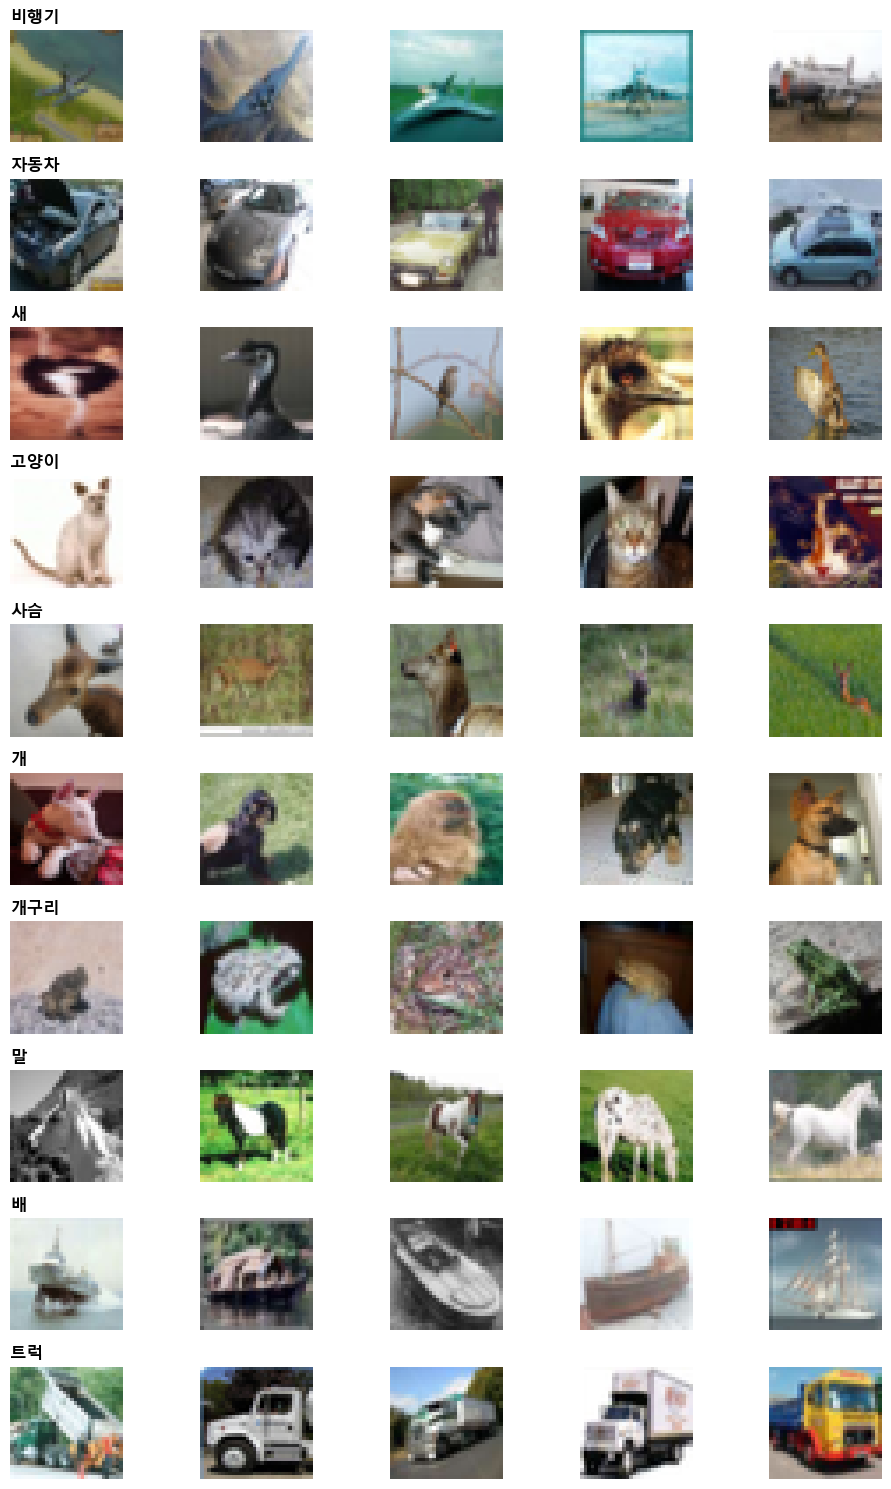

In [5]:
num_classes = 10
samples_per_class = 5

# 10행 5열의 서브플롯 생성
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(10, 15))

for cluster_idx, class_name in enumerate(classes):
    # 해당 클래스의 인덱스만 추출
    idx = np.flatnonzero(y_train == cluster_idx)
    # 무작위로 5개 선택
    rand_idx = np.random.choice(idx, samples_per_class, replace=False)

    for i, img_idx in enumerate(rand_idx):
        ax = axes[cluster_idx, i]
        ax.imshow(x_train[img_idx])
        ax.axis("off")

        # 첫 번째 열에만 클래스 이름 표시
        if i == 0:
            ax.set_title(class_name, loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

In [6]:
y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

In [7]:
y_train.shape, y_test.shape

((50000,), (10000,))

In [8]:
train_scaled = x_train / 255.0
test_scaled = x_test / 255.0

In [9]:
train_scaled.shape, test_scaled.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [10]:
model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)), # 입력층
    # Layer 1
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),
    # Layer 2 
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.MaxPool2D(2),

    keras.layers.Flatten(), # 평탄화 
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(10, activation='softmax') # 출력층
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       409,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 430,102 (1.64 MB)

 Trainable params: 430,102 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy'],
    jit_compile=False
)

In [13]:
checkpoint = keras.callbacks.ModelCheckpoint('chellange-best-model.keras', save_best_only=True)
early_stopping = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [14]:
history = model.fit(train_scaled, y_train, epochs=20,
                    validation_split=0.2, callbacks=[checkpoint, early_stopping])

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3692 - loss: 1.7112 - val_accuracy: 0.5318 - val_loss: 1.3543
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4984 - loss: 1.3840 - val_accuracy: 0.5744 - val_loss: 1.1917
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5525 - loss: 1.2502 - val_accuracy: 0.6094 - val_loss: 1.1166
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5884 - loss: 1.1533 - val_accuracy: 0.6381 - val_loss: 1.0239
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6126 - loss: 1.0844 - val_accuracy: 0.6527 - val_loss: 0.9921
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6356 - loss: 1.0212 - val_accuracy: 0.6641 - val_loss: 0.9712
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6597 - loss: 0.9580 - val_accuracy: 0.6728 - val_loss: 0.9395
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6718 - loss: 0.9199 -

In [15]:
print('최고 val_accuracy : ', max(history.history['val_accuracy']))

최고 val_accuracy :  0.7045999765396118


In [16]:
test_loss, test_acc = model.evaluate(test_scaled, y_test)

print("test_loss:", test_loss)
print("test_accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7051 - loss: 0.8818
test_loss: 0.8818150162696838
test_accuracy: 0.7050999999046326
